In [2]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata
from matplotlib.gridspec import GridSpec
import math
from matplotlib import ticker
import corner

In [3]:
# Get data
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
               '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21', 'Donnan+24']
sorted_data = edata.get_sorted(file_names, data_labels)

# Initialize parameters
param_dict = eMCMC.build_param_data({'dsigdz':{'fit':True}})

In [4]:
my_UVLF = eMCMC.UVLF(sorted_data, param_dict)

In [5]:
backend_file = '/Users/eb35267/Desktop/code/chains/min_sig_0.3/dsigdz/samples.h5'
samples, best_fit, _, _, log_prob= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, return_log_prob=True)

In [57]:
neg_dsigdz = np.where(samples[:,-1] <= 0)
best_neg_dsigdz = samples[neg_dsigdz][np.argmax(log_prob[neg_dsigdz])]

pos_dsigdz = np.where(samples[:,-1] > 0)
best_pos_dsigdz = samples[pos_dsigdz][np.argmax(log_prob[pos_dsigdz])]

In [58]:
best_neg_dsigdz

array([ 0.50858965, -1.8554591 , 11.87303744, -0.92578482,  0.30194156,
       -0.13076413])

In [59]:
best_pos_dsigdz

array([ 0.58302922, -0.83976297, 12.00614584, -0.74164814,  0.02258757,
        0.27403101])

In [145]:
comparison_fits = {'fits': [best_neg_dsigdz, best_pos_dsigdz],
                   'labels': ['more bursty \n' + r'at low $z$', 'more bursty \n' + r'at high $z$'], 
                   'linestyles':['solid', 'solid']}

In [146]:
def evolving_UVLF_fit(my_UVLF, backend_file = None, z_plot = None, z_errs = None, MUV_dat = None, ylims = None, plot_from_chain = True, nsamples = 100, comparison_dict = {}, ncols = 4, 
                      burn_in = None, show_chi2 = True, data_fmt = None):
    """
    Plot the UVLF at different redshifts
    Inputs:
        my_UVLF: eMCMC UVLF object
        backend_file [str]: .h5 file containing previously saved chain
        z_plot [list of floats]: redshifts to plot, or None if you want to plot all the redshifts for which there exists data
        z_errs [list of floats]: the uncertainty in redshift, or None if you want to use the uncertainty that corresponds to the data.
                                If you provide redshifts to plot but no redshift error, it will default to 0.5.
        MUV_dat [tuple of lists]: MUV bins & widths to plot. If None, defaults to the bins defined in my_UVLF.
        plot_from_chain [bool]: whether or not to plot the best fit and samples from the chain stored in my_UVLF. If False, only comparison_fits
                             parameter values will be plotted (so you can quickly check different fits this way).
        nsamples [int]: number of samples from the MCMC chain you want to appear in addition to the best fit
        comparison_dict [dict]: list the fits with the key 'fits' and the labels for those fits with the key 'labels'. Other keys include 'colors', 'linestyles', 'linewidths', 'max_sig', and 'zorder' but
                                there are default values if you don't specify 
        ncols [int]: number of columns to plot
        burn_in [int]: number of samples to discard as burnin. If None, the default value will be used (see UVLF.get_fit())
        show_chi2 [bool]: whether or not to show the chi squared of the fit(s). Does not apply if plot_from_chain is True
        data_fmt [list]: list of scatter plot styles
    Outputs:
        Figure showing the UVLF at different redshfits
    """

    data_z = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data

    if z_plot is None:
        z_plot = data_z
        z_errs = [dat[1] for dat in my_UVLF.data]
        dat = my_UVLF.data
    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float)
        if type(z_plot) == list:
            z_plot = np.array(z_plot)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

        idxs = np.concatenate([np.where(np.abs(data_z - z) < z_err)[0] for z, z_err in zip(z_plot, z_errs)])
        dat = [my_UVLF.data[i] for i in idxs]

    # Figure out how many subplots to make
    nz = len(z_plot)
    fig = plt.figure()
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    plt.subplots_adjust(wspace = 0, hspace = 0.3)
    
   
    # Get samples & best fit
    if plot_from_chain:
        samples, best_fit, _, _= my_UVLF.get_fit(backend_file = backend_file, exclude_unfit = True, burn_in = burn_in)
        print(best_fit)

    # Set the same y limits for all the plots
    # Flatten all ydat values from sorted_data
    all_ydat = np.concatenate([np.concatenate([ds[3] for ds in z_separated])  # ds[3] is ydat
                               for z_separated in my_UVLF.sorted_data])
    
    if ylims is None:
        ylo, yhi = np.log10(all_ydat.min()) - 1, np.log10(all_ydat.max()+3)
    else: 
        ylo, yhi = ylims


    # Flatten all xdat and xerr across all redshifts and datasets
    if MUV_dat is None:
        MUVcenters, MUVwidths = my_UVLF.get_all_MUV_bins()
    else:
        MUVcenters, MUVwidths = MUV_dat

    # Plotting details
    if data_fmt is None:
        data_fmt = ['o', 's', 'D', 'P']

    if comparison_dict is not {}: # Set defaults if none are given
        N = len(comparison_dict['fits'])
        comparison_dict.setdefault('colors', eplots.wrap(eplots.colors, N))
        comparison_dict.setdefault('linestyles', eplots.wrap(['solid', 'dashed', 'dashdot', 'dotted'], N))
        comparison_dict.setdefault('linewidths', np.full(N, 4))
        comparison_dict.setdefault('max_sigs', np.full(N, None))
        comparison_dict.setdefault('zorder', np.full(N, 1))


    axs = []
    for i, (z, z_err) in enumerate(zip(z_plot, z_errs)): 

        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)

        # Plot comparison fits
        if comparison_dict is not {}:
            for fit, label, color, ls, lw, max_sig, zorder in zip(comparison_dict['fits'], comparison_dict['labels'], comparison_dict['colors'], comparison_dict['linestyles'], comparison_dict['linewidths'], 
                                                                                                                                                                                comparison_dict['max_sigs'],
                                                                                                                                                                                comparison_dict['zorder']):
                if show_chi2:
                    chi2 = -2*my_UVLF.log_like(fit, dat)
                    fit_label = fr'{label}, $\chi^2 = {chi2:.0f}$'
                else:
                    fit_label = f'{label}'
                ax.plot(MUVcenters, np.log10(my_UVLF.UVLF_wrapper(z,z_err,MUVcenters, MUVwidths,fit, max_sig = max_sig)), color = color, 
                        label = fit_label, linestyle = ls, lw = lw, zorder = zorder)
        
        # Plot data
        all_dat_z = [dat[0][0] for dat in my_UVLF.sorted_data]
        idx = np.where(np.abs(all_dat_z - z) <= z_err)[0]
        if len(idx) > 0:
            for zbin in [my_UVLF.sorted_data[idx_i] for idx_i in idx]:
            #zbin = my_UVLF.sorted_data[idx[0]]

                for dat_z, fmt in zip(zbin, data_fmt): 
                    xdat, ydat, yerr_upper, yerr_lower, xerr, upper_lim_bool = dat_z[2], dat_z[3], dat_z[4], dat_z[5], dat_z[6], dat_z[7].astype('bool')
                    ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = eplots.navy, linewidth =5)
                    
                    # Show upper limits with a unique plotting style
                    for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                        ax.vlines(x, np.log10(y)-0.75, np.log10(y), ls = '-', colors = eplots.navy, linewidth = 5, alpha = 0.5)
                        ax.scatter(x-0.015, np.log10(y)-0.75, marker = 'v', c = eplots.navy, s = 65) # down arrow

                    if dat_z[-1]: # This indicates whether the data was used in the MCMC likelihood or not
                        for x, y in zip(xdat[upper_lim_bool], ydat[upper_lim_bool]):
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)
                        for x, y in zip(xdat[np.invert(upper_lim_bool)], ydat[np.invert(upper_lim_bool)]): # Account for the fact that upper limits cannot currently be included in the MCMC likelihood
                            ax.scatter(x, np.log10(y), marker = fmt, label = dat_z[8], c = eplots.navy, s = 125)
                    else: 
                        ax.scatter(xdat, np.log10(ydat), marker = fmt, label = dat_z[8], facecolors = 'white', edgecolors = eplots.navy, s = 125, 
                                zorder = 4, linewidth = 3)

        ax.invert_xaxis() 
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                    # axis labels                                                                            
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Make it so that only integers can be used in the  
                                                                                    # axis labels
        ax.set_title(fr'${round(z-z_err, 2)} \lesssim z \lesssim {round(z+z_err, 2)}$', fontsize = 20, pad = 8)
    
    return fig

Text(0, 0.5, '$\\log_{10}(\\phi_{\\rm{UV}}$ [$\\rm{mag}^{-1} \\rm{Mpc}^{-3}$])')

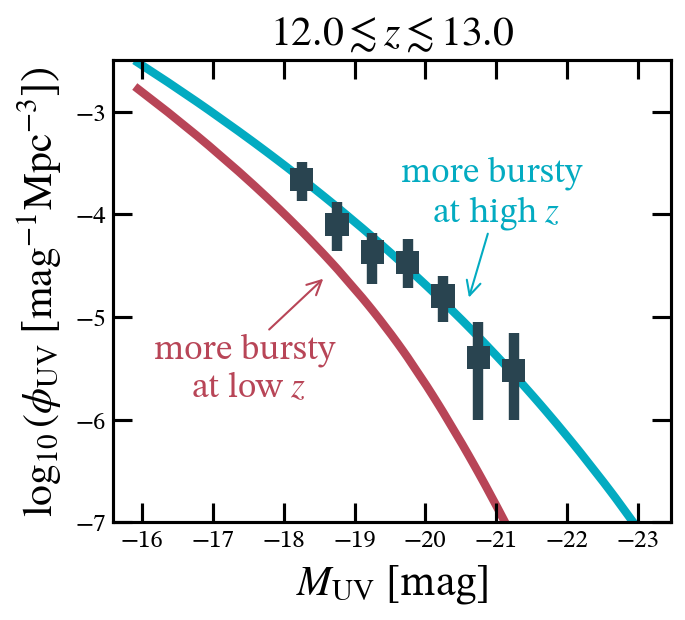

In [165]:
evolving_UVLF = evolving_UVLF_fit(my_UVLF, plot_from_chain=False, comparison_dict=comparison_fits, ncols = 5, show_chi2 = False, z_plot = [12.5])
evolving_UVLF.axes[0].set_ylim(-7, -2.5)
evolving_UVLF.set_size_inches(24, 4)
evolving_UVLF.axes[0].text(-17.5, -5.5, comparison_fits['labels'][0], ha = 'center', va = 'center', color = eplots.red)
evolving_UVLF.axes[0].text(-21, -3.8, comparison_fits['labels'][1], ha = 'center', va = 'center', color = eplots.turquoise)

ann = evolving_UVLF.axes[0].annotate('', xy=(-20.6, -4.85), xytext=(-20.9, -4.15),
                          arrowprops=dict(arrowstyle='->', color=eplots.turquoise, clip_on = False))

ann = evolving_UVLF.axes[0].annotate('', xy=(-18.6, -4.6), xytext=(-17.75, -5.15),
                          arrowprops=dict(arrowstyle='->', color=eplots.red, clip_on = False))

evolving_UVLF.axes[0].set_xlabel(r'$M_{\rm{UV}}$ [mag]')
evolving_UVLF.axes[0].set_ylabel(r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])')

In [166]:
evolving_UVLF.savefig('/Users/eb35267/Desktop/figures/FINESST_26/UVLF.png', dpi = 300)

# Bias

In [6]:
# Initialize parameters
param_dict = eMCMC.build_param_data({'dsigdlogM':{'fit':True}})

In [7]:
my_UVLF = eMCMC.UVLF(sorted_data, param_dict)

In [8]:
neg_dsigdM = [0.965, -0.447, 11.57, -0.772, 0.235, -0.925]

pos_dsigdM = [0.965, -0.447, 11.57, -0.772, 0.235, 0.925]

In [56]:
def bias(my_UVLF, compare_fits, fit_labels, ncols = 3, z_plot=None, z_errs=None, fit_colors = None):
    """
    Plot bias vs. bias data
    
    :param my_UVLF: [eMCMC UVLF object] UVLF object used for its methods such as applying time evolution to parameter values & wrapping them in the
                                        right format for zeus21
    :param compare_fits: [list of lists] different fits to compare the bias calculations for
    :param fit_labels: [list] labels for each of compare_fits
    :param ncols: [int] number of columns for plotting
    :param z_plot: [list] redshifts to plot. If None, will default to the redshifts of the data
    :param z_errs: [list] redshift uncertainty. If None, will default to the zerr of the data or 0.5
    """

    if z_plot is None:
        z_plot = [dat[0] for dat in my_UVLF.data] # Get the redshifts that correspond to the input data
        z_errs = [dat[1] for dat in my_UVLF.data] # Get redshift error from data
        dat = my_UVLF.data
    else:
        if z_errs is None:
            z_errs = np.full_like(z_plot, 0.5, dtype = float) # If the user provides z but not zerr, default to 0.5 for each redshift
        if type(z_plot) == list:
            z_plot = np.array(z_plot)
        if type(z_errs) == list:
            z_errs = np.array(z_errs)

    nz = len(z_plot)
    fig = plt.figure()
    fig.set_size_inches(22, 3)
    gs = GridSpec(math.ceil((nz+1)/ncols), ncols, figure=fig)
    plt.subplots_adjust(wspace = 0, hspace = 0.3)

    MUVcenters, MUVwidths = my_UVLF.get_all_MUV_bins()

    # Hard code bias data for now
    bias_data = np.loadtxt('/Users/eb35267/Desktop/code/home/data/bias.txt', unpack = True)

    if fit_colors is None:
        fit_colors = [eplots.turquoise, eplots.yellow, eplots.orange, eplots.green]

    axs = []
    all_bias = []
    for i, (z, zerr) in enumerate(zip(z_plot, z_errs)):
        ax = fig.add_subplot(gs[math.floor(i/ncols), i%ncols])
        axs.append(ax)
        z_bias = []
        for (fit, label, color, ls) in zip(compare_fits, fit_labels, fit_colors, ['solid', 'dashdot', 'dotted', 'dashed']): 
            _, bias = my_UVLF.UVLF_wrapper(z, zerr, MUVcenters, MUVwidths, fit, get_bias = True)
            z_bias.append(bias)
            ax.plot(MUVcenters, bias, ls = ls, color = color, label = label)

        ax.set_title(fr'${round(z-zerr, 1)} \lesssim z \lesssim {round(z+zerr, 1)}$', fontsize = 17, pad = 8)
        ax.invert_xaxis()
        all_bias.append(np.concatenate(z_bias))
        bias_inds = ((bias_data[0] < z + zerr) & (bias_data[0] > z - zerr))
        ax.errorbar(bias_data[1][bias_inds], bias_data[2][bias_inds], yerr = bias_data[3][bias_inds], fmt = 'o', markeredgewidth=0, 
                    color = eplots.navy, label = 'Muñoz+23 effective bias', markersize = 9)

    xlabel = r'$M_{\rm{UV}}$ [mag]'
    ylabel = r'$b(M_{\rm{UV}})$'
    axs[0].set_xlabel(xlabel, fontsize = 17)
    axs[0].set_ylabel(ylabel, fontsize = 17)

    # Flatten all ydat values from sorted_data to get the min and max
    all_ydat = np.concatenate([np.concatenate([ds[3] for ds in z_separated])  # ds[3] is ydat
                                for z_separated in my_UVLF.sorted_data])

    all_bias = np.concatenate(all_bias)
    ylims = (np.min(all_bias)-1, np.max(all_bias)+0.25)

    # axs[0].set_ylim(ylims)
    axs[0].set_xlim((-15.5, -24))

    return fig

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude


Text(-24.5, 12.9, 'more clustered')

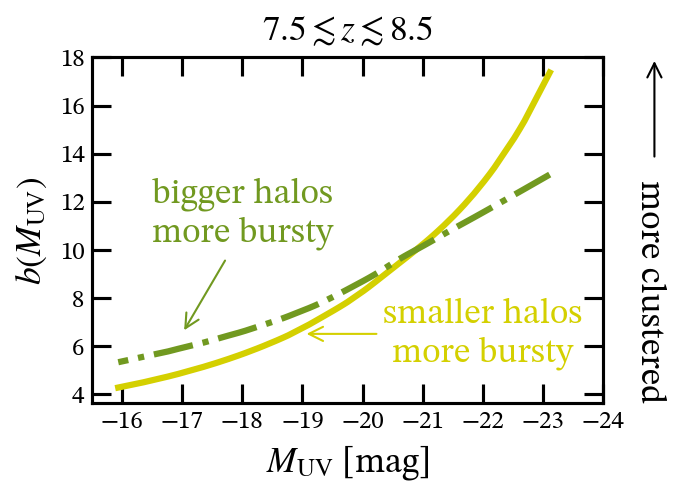

In [93]:
bias_fig = bias(my_UVLF, compare_fits = [neg_dsigdM, pos_dsigdM], fit_labels = ['neg dsigdM', 'pos dsigdM'], fit_colors = [eplots.yellow, eplots.green], ncols = 5, z_plot = [8.])

bias_fig.axes[0].text(-22, 6.5, 'smaller halos\nmore bursty', ha = 'center', va = 'center', color = eplots.yellow, fontsize = 17)
bias_fig.axes[0].text(-18, 11.5, 'bigger halos\nmore bursty', ha = 'center', va = 'center', color = eplots.green, fontsize = 17)

ann = bias_fig.axes[0].annotate('', xy=(-17, 6.5), xytext=(-17.75, 9.7),
                          arrowprops=dict(arrowstyle='->', color=eplots.green, clip_on = False))

ann = bias_fig.axes[0].annotate('', xy=(-19, 6.5), xytext=(-20.3, 6.5),
                          arrowprops=dict(arrowstyle='->', color=eplots.yellow, clip_on = False))


ann = bias_fig.axes[0].annotate('', xy=(1.1, 1), xytext=(1.1, 0.7), xycoords='axes fraction',
                          arrowprops=dict(arrowstyle='->', color='black', clip_on = False))
bias_fig.axes[0].text(-24.5, 12.9, 'more clustered', ha='left', va='top',
                      rotation=-90, fontsize = 17)

In [94]:
bias_fig.savefig('/Users/eb35267/Desktop/figures/FINESST_26/bias.png', dpi = 300)

# Corner

In [5]:
samples_best_fit = np.loadtxt('/Users/eb35267/Desktop/code/chains/flattened_best_fit.txt')

red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


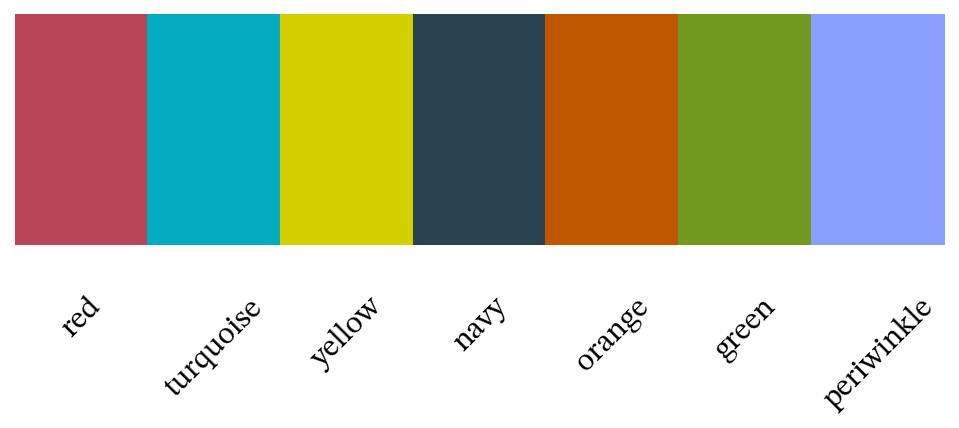

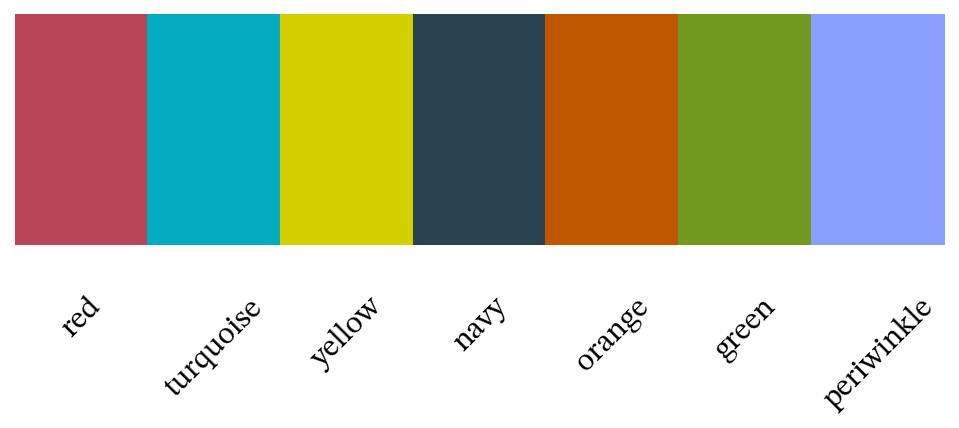

In [21]:
eplots.plot_colors()

Text(0.25, 6.4, 'more bursty at high $z$')

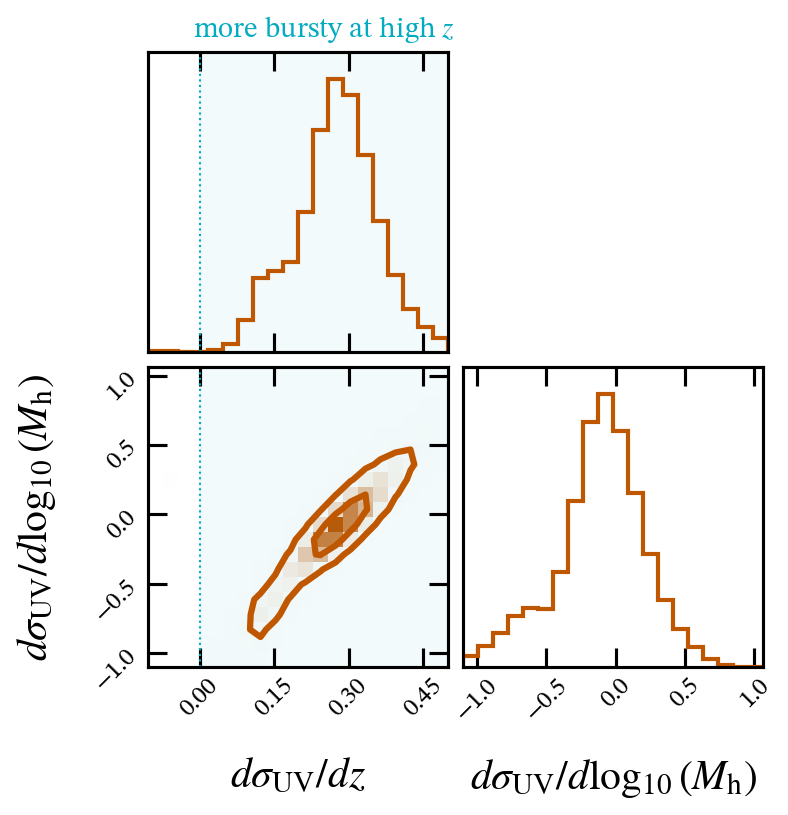

In [227]:
corner_plot = corner.corner(samples_best_fit[:, [-2, -1]], labels= [r'$d\sigma_{\rm{UV}}/dz$', r'$d\sigma_{\rm{UV}}/d\log_{10}(M_{\rm{h}})$'], 
                            color = eplots.orange, plot_contours = True, plot_datapoints = False, 
                            hist_kwargs={'linewidth': 2, 'density': True, 'linestyle': 'solid'}, 
                            levels = (0.393, 0.864))

# corner_plot.axes[2].fill_between([-1, 1], -0.34, -0.21, color = eplots.periwinkle, alpha = 0.3, zorder = 1)
# corner_plot.axes[3].fill_between([-0.34, -0.21], 0, 1e6, color = eplots.periwinkle, alpha = 0.3, zorder = 0)

corner_plot.axes[0].axvline(0, color = eplots.turquoise, linewidth = 1, linestyle = 'dotted')
corner_plot.axes[2].axvline(0, color = eplots.turquoise, linewidth = 1, linestyle = 'dotted')
# corner_plot.axes[1].plot(0, 0, color = eplots.turquoise, label = 'minimal')
# corner_plot.axes[1].plot(0, 0, linestyle = 'solid', color = eplots.yellow, label = 'best fit')
# corner_plot.axes[1].fill_between([0,0], 0, 0, color = eplots.periwinkle, alpha = 0.3, label = 'Gelli+24,\nMuñoz+26')
# corner_plot.axes[1].legend()

# ann = corner_plot.axes[2].annotate('', xy=(0.075, 0), xytext=(-0.01, 0), 
#                           arrowprops=dict(arrowstyle='->', color=eplots.turquoise, clip_on = False))
# ann = corner_plot.axes[0].annotate('', xy=(0.075, 3), xytext=(-0.01, 3), 
#                           arrowprops=dict(arrowstyle='->', color=eplots.turquoise, clip_on = False))

corner_plot.axes[2].fill_between([0, 0.5], -1.5, 1.5, color = eplots.turquoise, zorder = 1, alpha = 0.05)
corner_plot.axes[0].fill_between([0, 0.5], -1.5, 10, color = eplots.turquoise, zorder = 0, alpha = 0.05)
corner_plot.axes[0].text(0.25, 6.4, r'more bursty at high $z$', ha='center', va='center', fontsize = 14, color = eplots.turquoise)

In [228]:
corner_plot.savefig('/Users/eb35267/Desktop/figures/FINESST_26/corner.png', dpi = 300)